# Facial Expression Recognition using CNN

## Course Assignment
This notebook presents a custom CNN model for facial expression recognition using the FER-2013 dataset. The main objective is to classify facial images into 7 emotion categories and evaluate the model using different performance metrics and visualizations.

In [1]:
#cell 1
#libraries
!pip install -q datasets evaluate torchinfo scikit-learn

In [2]:
#cell 2
from datasets import load_dataset, load_dataset_builder

# Inspect dataset
builder = load_dataset_builder("sxj1215/fer2013")
print(builder.info)

# Load dataset
dataset = load_dataset("sxj1215/fer2013")
print(dataset)

# sample
sample = dataset["train"][0]
print(sample.keys())
print(sample)

DatasetInfo(description='', citation='', homepage='', license='', features={'messages': List({'role': Value('string'), 'content': Value('string')}), 'images': List(Image(mode=None, decode=True))}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='fer2013', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=54203899, num_examples=28709, shard_lengths=None, original_shard_lengths=None, dataset_name='fer2013')}, download_checksums={'hf://datasets/sxj1215/fer2013@dd92ea0dc1992902769b0ac3cfe8b72006ed02e1/data/train-00000-of-00001.parquet': {'num_bytes': 43096970, 'checksum': None}}, download_size=43096970, post_processing_size=None, dataset_size=54203899, size_in_bytes=97300869)
DatasetDict({
    train: Dataset({
        features: ['messages', 'images'],
        num_rows: 28709
    })
})
dict_keys(['messages', 'images'])
{'messages': [{'role': 'user', 'content': 'Given an image of a facial expression, the task is to catego

In [3]:
#cell 3
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from datasets import load_dataset
from torchvision import transforms
from PIL import Image

# seed set to 15 for Reproducibility
SEED = 15
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Data Preprocessing and Augmentation

The images are preprocessed before training. Since the images are small grayscale facial images, they are resized to 48×48 and normalized.

In [4]:
#cell 4

# loading dataset
dataset = load_dataset("sxj1215/fer2013")
print(dataset)
print("Available splits:", list(dataset.keys()))

first_split_name = list(dataset.keys())[0]
print("First split name:", first_split_name)

DatasetDict({
    train: Dataset({
        features: ['messages', 'images'],
        num_rows: 28709
    })
})
Available splits: ['train']
First split name: train


In [5]:
#cell 5
# split dataset

from datasets import DatasetDict

if "train" in dataset and "test" in dataset:
    train_valid = dataset["train"].train_test_split(test_size=0.15, seed=SEED)
    train_ds_raw = train_valid["train"]
    val_ds_raw = train_valid["test"]
    test_ds_raw = dataset["test"]

else:
    full_ds = dataset[first_split_name]

    temp = full_ds.train_test_split(test_size=0.15, seed=SEED)
    train_val_ds = temp["train"]
    test_ds_raw = temp["test"]

    temp2 = train_val_ds.train_test_split(test_size=0.1765, seed=SEED)
    train_ds_raw = temp2["train"]
    val_ds_raw = temp2["test"]

print("Train size:", len(train_ds_raw))
print("Validation size:", len(val_ds_raw))
print("Test size:", len(test_ds_raw))
print(len(train_ds_raw))

Train size: 20095
Validation size: 4307
Test size: 4307
20095


## Dataset Loading and Exploration

In this section, the FER-2013 dataset is loaded and inspected. The dataset contains grayscale facial images and corresponding emotion labels.

In [6]:
#cell 6
# preprocessing, transforms, labels, and dataloaders

from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image
import torch

# Correct dataset keys for this FER-2013 version
image_col = "images"
label_source_col = "messages"

# Label mapping
label_to_idx = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5,
    "neutral": 6
}

idx_to_label = {v: k for k, v in label_to_idx.items()}

# Image settings
IMG_SIZE = 48
BATCH_SIZE = 64

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08))
])

# Validation and test preprocessing
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

def extract_label_from_messages(messages):
    """
    Extract the emotion label from the assistant reply.
    """
    for msg in messages:
        if msg["role"] == "assistant":
            label_text = msg["content"].strip().lower()
            return label_to_idx[label_text]
    raise ValueError("No assistant label found in messages.")

def extract_image_from_images(images):
    """
    This dataset stores images inside a list.
    We take the first image and convert it to grayscale.
    """
    img = images[0]
    if not isinstance(img, Image.Image):
        raise ValueError(f"Expected PIL image, got {type(img)}")
    return img.convert("L")

def train_transform_fn(examples):
    return {
        "pixel_values": [train_transform(extract_image_from_images(x)) for x in examples[image_col]],
        "labels": [extract_label_from_messages(x) for x in examples[label_source_col]]
    }

def eval_transform_fn(examples):
    return {
        "pixel_values": [eval_transform(extract_image_from_images(x)) for x in examples[image_col]],
        "labels": [extract_label_from_messages(x) for x in examples[label_source_col]]
    }

# Attach transforms
train_ds = train_ds_raw.with_transform(train_transform_fn)
val_ds = val_ds_raw.with_transform(eval_transform_fn)
test_ds = test_ds_raw.with_transform(eval_transform_fn)

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
    return pixel_values, labels

# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)
print("train_ds ready:", len(train_ds))
print("train_loader ready")
print("DataLoaders created successfully.")

train_ds ready: 20095
train_loader ready
DataLoaders created successfully.


In [7]:
#cell 7
# batch check

images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Unique labels in batch:", torch.unique(labels))

Image batch shape: torch.Size([64, 1, 48, 48])
Label batch shape: torch.Size([64])
Unique labels in batch: tensor([0, 2, 3, 4, 5, 6])


## CNN Architecture

In this section, custom CNN architectures are defined. A baseline CNN is created first, followed by an improved CNN with batch normalization and dropout. These additions help improve training stability and model performance.

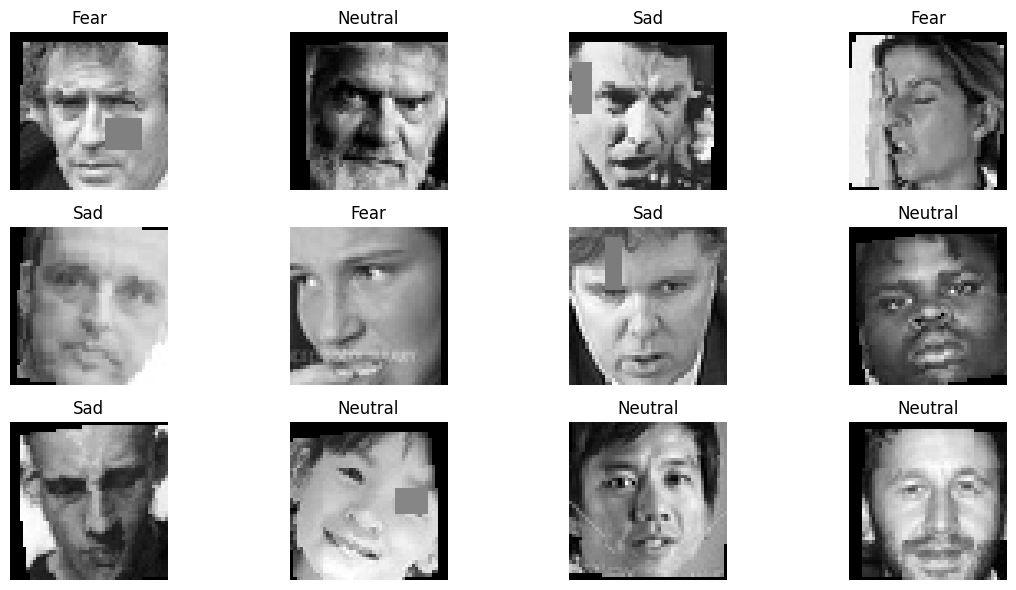

In [8]:
#cell 8
class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    img = images[i].squeeze(0).cpu().numpy()
    img = (img * 0.5) + 0.5
    plt.imshow(img, cmap="gray")
    label_idx = int(labels[i].item())
    if 0 <= label_idx < len(class_names):
        plt.title(class_names[label_idx])
    else:
        plt.title(f"Class {label_idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
#cell 9
from torchinfo import summary
import torch
import torch.nn as nn

NUM_CLASSES = 7

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()
        # Feature extraction layers
        # image shape [batch_size, 1, 48, 48]

        self.features = nn.Sequential(

            # 1st convolution block
            # Output [batch_size, 32, 48, 48]
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # Output: [batch_size, 32, 24, 24]

            # 2nd convolution block
            # Output [batch_size, 64, 24, 24]
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # Output: [batch_size, 64, 12, 12]

            # 3rd convolution block
            # Output: [batch_size, 128, 12, 12]
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # Output: [batch_size, 128, 6, 6]

            # 4th convolution block
            # Output: [batch_size, 256, 6, 6]
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)    # Output: [batch_size, 256, 3, 3]
        )

        # Classification layers
        # Flattened size = 256 * 3 * 3 = 2304
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    # Forward pass--Classify into one of 7 emotion classes

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
#cell 10
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [11]:
#cell 11
# baseline architecture summary
summary(baseline_model, input_size=(64, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
BaselineCNN                              [64, 7]                   --
├─Sequential: 1-1                        [64, 256, 3, 3]           --
│    └─Conv2d: 2-1                       [64, 32, 48, 48]          320
│    └─ReLU: 2-2                         [64, 32, 48, 48]          --
│    └─MaxPool2d: 2-3                    [64, 32, 24, 24]          --
│    └─Conv2d: 2-4                       [64, 64, 24, 24]          18,496
│    └─ReLU: 2-5                         [64, 64, 24, 24]          --
│    └─MaxPool2d: 2-6                    [64, 64, 12, 12]          --
│    └─Conv2d: 2-7                       [64, 128, 12, 12]         73,856
│    └─ReLU: 2-8                         [64, 128, 12, 12]         --
│    └─MaxPool2d: 2-9                    [64, 128, 6, 6]           --
│    └─Conv2d: 2-10                      [64, 256, 6, 6]           295,168
│    └─ReLU: 2-11                        [64, 256, 6, 6]           --
│

In [12]:
#cell 12
# improved CNN for emotion detection

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
#cell 13
#improved model to gpu
improved_model = ImprovedCNN(num_classes=NUM_CLASSES).to(device)
print(improved_model)

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(

In [14]:
#cell 14
# Improved Model architecture summary
summary(improved_model, input_size=(64, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
ImprovedCNN                              [64, 7]                   --
├─Sequential: 1-1                        [64, 256, 3, 3]           --
│    └─Conv2d: 2-1                       [64, 32, 48, 48]          320
│    └─BatchNorm2d: 2-2                  [64, 32, 48, 48]          64
│    └─ReLU: 2-3                         [64, 32, 48, 48]          --
│    └─Conv2d: 2-4                       [64, 32, 48, 48]          9,248
│    └─BatchNorm2d: 2-5                  [64, 32, 48, 48]          64
│    └─ReLU: 2-6                         [64, 32, 48, 48]          --
│    └─MaxPool2d: 2-7                    [64, 32, 24, 24]          --
│    └─Conv2d: 2-8                       [64, 64, 24, 24]          18,496
│    └─BatchNorm2d: 2-9                  [64, 64, 24, 24]          128
│    └─ReLU: 2-10                        [64, 64, 24, 24]          --
│    └─Conv2d: 2-11                      [64, 64, 24, 24]          36,928
│ 

## Training Setup

The model is trained using cross-entropy loss and the Adam optimizer. A learning rate scheduler is used to reduce the learning rate when validation performance stops improving. The best model is saved during training based on validation accuracy.

In [15]:
#cell 15
# TRAINING SETUP

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

model = ImprovedCNN(num_classes=NUM_CLASSES).to(device)

train_labels_list = [
    extract_label_from_messages(train_ds_raw[i]["messages"])
    for i in range(len(train_ds_raw))
]

label_counts = Counter(train_labels_list)

class_counts = np.array([label_counts.get(i, 1) for i in range(NUM_CLASSES)])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

EPOCHS = 35
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

Class counts: [2710  323 2831 5047 3440 2263 3481]
Class weights: tensor([0.5129, 4.3032, 0.4910, 0.2754, 0.4041, 0.6142, 0.3993],
       device='cuda:0')


## Model Training

This section contains the training and validation loop. During each epoch, the model is trained on the training set and evaluated on the validation set. Training loss, validation loss, training accuracy, and validation accuracy are recorded for later analysis.

In [16]:
#cell 16
# Train / Validate

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Save best model based
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_fer2013_model.pth")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

# Load best weights after training
model.load_state_dict(best_model_wts)

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("Best model saved as: best_fer2013_model.pth")

Epoch [1/35] | Train Loss: 1.9163, Train Acc: 0.1977 | Val Loss: 1.8317, Val Acc: 0.1528 | LR: 0.000500
Epoch [2/35] | Train Loss: 1.8147, Train Acc: 0.2397 | Val Loss: 1.6913, Val Acc: 0.3836 | LR: 0.000500
Epoch [3/35] | Train Loss: 1.7028, Train Acc: 0.3611 | Val Loss: 1.6181, Val Acc: 0.3915 | LR: 0.000500
Epoch [4/35] | Train Loss: 1.6372, Train Acc: 0.3837 | Val Loss: 1.5252, Val Acc: 0.4416 | LR: 0.000500
Epoch [5/35] | Train Loss: 1.5758, Train Acc: 0.4111 | Val Loss: 1.5487, Val Acc: 0.4416 | LR: 0.000500
Epoch [6/35] | Train Loss: 1.5134, Train Acc: 0.4207 | Val Loss: 1.4203, Val Acc: 0.4314 | LR: 0.000500
Epoch [7/35] | Train Loss: 1.4640, Train Acc: 0.4454 | Val Loss: 1.4089, Val Acc: 0.4476 | LR: 0.000500
Epoch [8/35] | Train Loss: 1.4333, Train Acc: 0.4609 | Val Loss: 1.3533, Val Acc: 0.4653 | LR: 0.000500
Epoch [9/35] | Train Loss: 1.4102, Train Acc: 0.4684 | Val Loss: 1.3302, Val Acc: 0.4662 | LR: 0.000500
Epoch [10/35] | Train Loss: 1.3752, Train Acc: 0.4771 | Val Loss

## Model Evaluation

After training, the best saved model is evaluated on the test set. The performance is analyzed using accuracy, precision, recall, F1-score, and confusion matrix.

Test Loss: 1.1359
Test Accuracy: 0.6106

Classification Report:

              precision    recall  f1-score   support

       Angry     0.5648    0.4896    0.5245       623
     Disgust     0.3333    0.5577    0.4173        52
        Fear     0.5481    0.2316    0.3256       639
       Happy     0.8060    0.8699    0.8367      1084
         Sad     0.4671    0.5179    0.4912       699
    Surprise     0.6332    0.8151    0.7128       449
     Neutral     0.5378    0.6268    0.5789       761

    accuracy                         0.6106      4307
   macro avg     0.5558    0.5869    0.5553      4307
weighted avg     0.6067    0.6106    0.5961      4307



<Figure size 800x800 with 0 Axes>

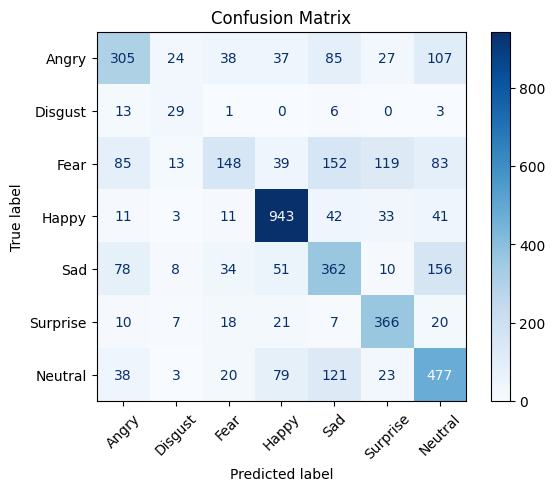


Per-class Accuracy:
Angry: 0.4896
Disgust: 0.5577
Fear: 0.2316
Happy: 0.8699
Sad: 0.5179
Surprise: 0.8151
Neutral: 0.6268

Best performing class: Happy (0.8699)
Worst performing class: Fear (0.2316)


In [17]:
#cell 17
# TEST EVALUATION
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)
print("\nClassification Report:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix")
plt.show()

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class Accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"{class_names[i]}: {acc:.4f}")

best_class_idx = np.argmax(per_class_acc)
worst_class_idx = np.argmin(per_class_acc)

print(f"\nBest performing class: {class_names[best_class_idx]} ({per_class_acc[best_class_idx]:.4f})")
print(f"Worst performing class: {class_names[worst_class_idx]} ({per_class_acc[worst_class_idx]:.4f})")

## Visualizations

Training and validation loss/accuracy curves are plotted to show how the model learned over time.

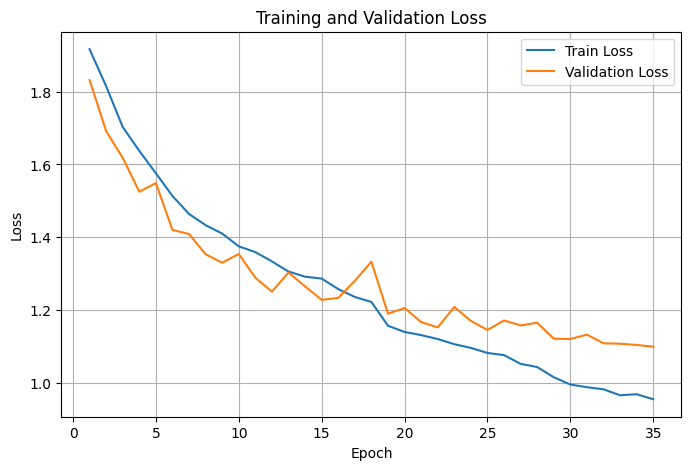

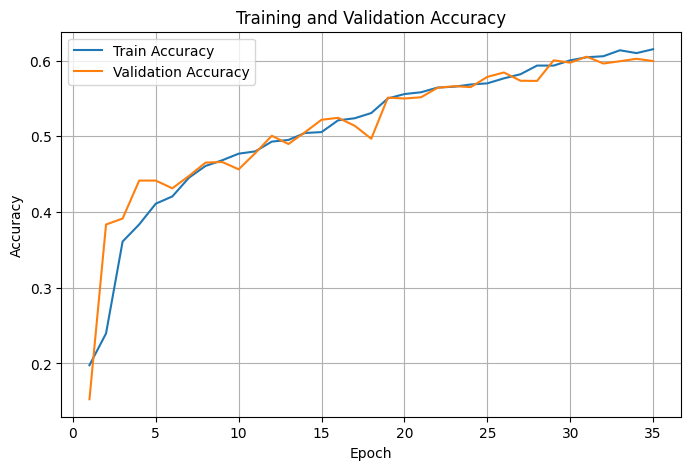

In [18]:
#cell 18
# TRAINING CURVES

epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import sys, torch

print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch file:", torch.__file__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("cuDNN available:", torch.backends.cudnn.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python exe: c:\Users\zephrox\Desktop\Machine Learning Projects\CVPR\CNN_22-49235-3\.venv\Scripts\python.exe
Torch version: 2.5.1+cu121
Torch file: c:\Users\zephrox\Desktop\Machine Learning Projects\CVPR\CNN_22-49235-3\.venv\Lib\site-packages\torch\__init__.py
CUDA available: True
Torch CUDA version: 12.1
cuDNN available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Conclusion

In this project, a custom CNN was developed for facial expression recognition using the FER-2013 dataset. The model was trained and evaluated using preprocessing, augmentation, regularization, and learning rate scheduling.

The final model achieved reasonable performance on a challenging dataset and showed that a custom CNN can learn useful facial expression features. Future improvements could include deeper architectures, more hyperparameter tuing.

CVPR Course- Mid Term Assignment 
MD ANJIR JAMAN
22-49235-3